# Exercises

## Exercise 1
---

You can find below the code that was used to generate the activity of place cells on a linear track.
Use the code and the decoding procedure you lerned about in the lesson to explore how different features of the data impact our ability to decode position.
In particular:

A - Try to use different fractions of our data samples. How does the median error change when the the number of available sample gets larger? You do not need to re-generate any data, just randomly sub-sample the data to different fractions.

B - How many place cells do we need to reliably decode position? Try to re-do the decoding using only 10 cell, then 20, and so on. How does the median error change? Does it reach an asymptote? (Also in this case, you do not need to re-generate the data, you can just select a random subset of cells each time)

C - Generate new data using the code below, changing the firing rate noise (changing the value of the variable `noise firing_rate`). How does this noise impact the decoding? 

In [79]:
import os

os.chdir("C:/Users/larsb/Cognitive_neuroscience_RU/neuro-analysis-nongit/population-methods-main/01-bayes-decoding")


In [2]:
#A
import pickle
import numpy as np
import ipywidgets as widgets
from ipywidgets import interact
import matplotlib.pyplot as plt
from tqdm import tqdm
import seaborn as sns
from scipy.stats import pearsonr
import sys
import os
sys.path.append(os.path.abspath("code"))
from utils import download_data

sns.set_theme(context='notebook',style='white',font_scale=1.5,
              rc = {'axes.spines.top':False,'axes.spines.right':False})

In [26]:
download_data('https://surfdrive.surf.nl/files/index.php/s/TliAW2xObyy0keu')

#code: data import
data_file = 'data/linear_track_data.pickle'
with open(data_file, 'rb') as handle:
    data = pickle.load(handle)

x,t,spikes = data['x'],data['t'],data['spikes']
track_length = data['track_length']
fps = data['fps'] 
n_cells = len(spikes)

In [4]:
def plot_unit(i):
    plt.plot(t, x)
    plt.plot(spikes[i], np.interp(spikes[i], t, x), 'r.')
    
interact(plot_unit, i = widgets.IntSlider(min=0, max=(n_cells-1), value=0))

interactive(children=(IntSlider(value=0, description='i', max=99), Output()), _dom_classes=('widget-interact',…

<function __main__.plot_unit(i)>

In [28]:
# we compute the poistion at which each spike was emitted
spike_positions = [np.interp(s, t, x) for s in spikes]
space_bins = np.arange(0., track_length, 5.) # binning in bins of 5 cms

# we compute histograms for each cell
spikes_hist= [np.histogram(s, space_bins)[0] for s in spike_positions]
spikes_hist = np.asarray(spikes_hist)

# we also need an "occupancy histogram" in order to normalize the firing rates maps 
occupancy = np.histogram(x, space_bins)[0] /  fps

firing_rate_maps = spikes_hist / occupancy 

spikes_count= [np.histogram(s,t)[0] for s in spikes]
spikes_count = np.asarray(spikes_count).T # we transpose the matrix to have the more familiar (samples x features) shape

In [6]:
# code decoding
from scipy.stats import poisson

true_x = x[:-1] # get rid of last timepoint to have same length as binned spikes
decoding_times = t[:-1]

x_decoded = np.zeros_like(true_x)

for t_bin in tqdm(range(len(decoding_times))):
    if sum(spikes_count[t_bin,:])>0: # Check if the time window contains spikes
        posterior = np.empty(firing_rate_maps.shape[-1])

        for i in range(len(posterior)):
            # Note that we work with log so that we can sum probabilities
            # instead of multiplying them 
            #posterior[i] = sum(np.log(poisson.pmf(spikes_count[t_bin,:],firing_rate_maps[:,i]/fps)+pow(1,-15)))
            posterior[i] = sum(poisson.logpmf(spikes_count[t_bin,:],firing_rate_maps[:,i]/fps)+pow(10,-15))


        x_decoded[t_bin] = space_bins[np.argmax(posterior)]
    else:
        x_decoded[t_bin] = np.nan   


100%|██████████| 5026/5026 [00:07<00:00, 661.30it/s]


In [ ]:
# Decode only a fraction of the positions data and do it 5 times per fraction 
# to later also plot the standard error
# I don't fuly understand whether this is what the excersize asks for
# But I think this is what the excersize means
fractions = [0.1, 0.25, 0.5, 0.75, 1]
repeats = 5

results = {f:[] for f in fractions}

true_x = x[:-1] # get rid of last timepoint to have same length as binned spikes
decoding_times = t[:-1]

x_decoded = np.zeros_like(true_x)

for frac in fractions:
    for n in range(repeats):
        sample_n = int(len(decoding_times)*frac)
        idx = np.random.choice(len(decoding_times), sample_n, replace = False)
        true_x_sub = true_x[idx]

        x_decoded_sub = np.zeros_like(true_x_sub)

        for t_bin in tqdm(range(len(idx))):

            if sum(spikes_count[idx[t_bin],:])>0: # Check if the time window contains spikes
                posterior = np.empty(firing_rate_maps.shape[-1])

                for i in range(len(posterior)):
            # Note that we work with log so that we can sum probabilities
            # instead of multiplying them 
            #posterior[i] = sum(np.log(poisson.pmf(spikes_count[t_bin,:],firing_rate_maps[:,i]/fps)+pow(1,-15)))
                    posterior[i] = sum(poisson.logpmf(spikes_count[idx[t_bin],:],firing_rate_maps[:,i]/fps)+pow(10,-15))

                x_decoded_sub[t_bin] = space_bins[np.argmax(posterior)]
            else:
                x_decoded_sub[t_bin] = np.nan

        results[frac].append(np.nanmedian(np.sqrt((true_x_sub-x_decoded_sub)**2)))

In [ ]:
# calculate the mean and standard deviation of the median error per fraction
mean_f = []
std_f = []


for f in fractions:
    mean_f.append(np.mean(results[f]))
    std_f.append(np.std(results[f]))


#plot the mean error against the fraction of data including error bars

plt.errorbar(fractions, mean_f, std_f, marker = "o")
plt.ylim(3,4)
plt.title("The median error per fraction of data selected")
plt.xlabel("fraction of data")
plt.ylabel("median error")

# As you can see in the plot, the median error stays relatively stable
# Across all fractions of data used, which makes sense because the firing rate maps
# and spike counts remain unchanged, however over the 5 repitions per fraction
# the variation in median error becomes larger, because when you decrease the amount of data used
# the effect of a hard to decode point becomes bigger.

In [7]:
#B
# Make a function in which you can put in the amount of neurons
# you want to use to decode the position
def neuron_number(number):
    idx = np.random.randint(spikes_count.shape[1], size=number)

    spikes_count_sub = spikes_count[:, idx]

    firing_rate_maps_sub = firing_rate_maps[idx, :]

    true_x = x[:-1] # get rid of last timepoint to have same length as binned spikes
    decoding_times = t[:-1]

    x_decoded = np.zeros_like(true_x)

    for t_bin in tqdm(range(len(decoding_times))):
        if sum(spikes_count_sub[t_bin,:])>0: # Check if the time window contains spikes
            posterior = np.empty(firing_rate_maps_sub.shape[-1])

            for i in range(len(posterior)):
                # Note that we work with log so that we can sum probabilities
                # instead of multiplying them 
             #posterior[i] = sum(np.log(poisson.pmf(spikes_count_sub[t_bin,:],firing_rate_maps[:,i]/fps)+pow(1,-15)))
                posterior[i] = sum(poisson.logpmf(spikes_count_sub[t_bin,:],firing_rate_maps_sub[:,i]/fps)+pow(10,-15))


            x_decoded[t_bin] = space_bins[np.argmax(posterior)]
        else:
            x_decoded[t_bin] = np.nan   

    return x_decoded


    




In [8]:
# Decode the position using a varaity of neurons
x_decoded_ten = neuron_number(10)
x_decoded_twenty = neuron_number(20)
x_decoded_forty = neuron_number(40)
x_decoded_sixty = neuron_number(60)
x_decoded_eigthy = neuron_number(80)
x_decoded_hundred = neuron_number(100)

full_decoded = [x_decoded_ten,
                x_decoded_twenty,
                x_decoded_forty,
                x_decoded_sixty,
                x_decoded_eigthy,
                x_decoded_hundred]

100%|██████████| 5026/5026 [00:06<00:00, 772.00it/s]


In [9]:
# error distribution
true_x = x[:-1]
median_errors = []

for i in range(len(full_decoded)):
    mse = np.sqrt((true_x-full_decoded[i])**2)
    median_errors.append(np.nanmedian(mse))

Text(0, 0.5, 'median error')

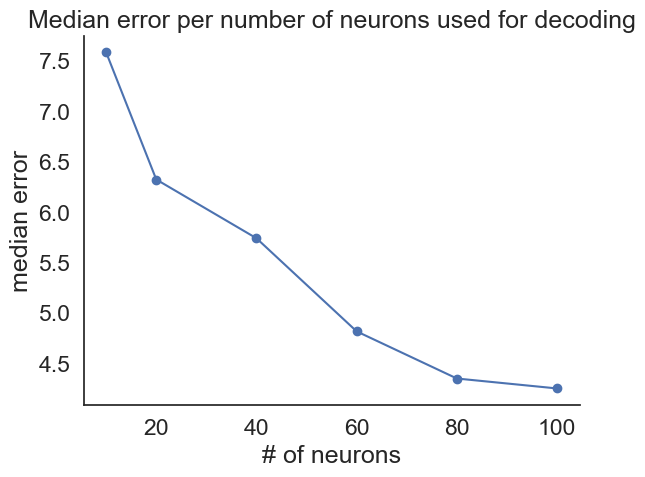

In [10]:
# plot the error per number of neurons used
cell_number = [10, 20, 40, 60, 80, 100]

plt.plot(cell_number, median_errors, marker = "o")
plt.title("Median error per number of neurons used for decoding")
plt.xlabel("# of neurons")
plt.ylabel("median error")

# As you can see the median error decreases as you include more neurons
# to decode the position, which makes sense as using less place cells
# you have less information about the position, so the decoder gets less
# certain about the position and the median error increases

In [17]:
# At the bottom I made a dictionary with spikes per noise added
# Next firing rate maps per noise rate are created
# we compute the poistion at which each spike was emitted
spikes_count = {n:[] for n in noise_firing_rate}
firing_rate_maps = {n:[] for n in noise_firing_rate}


for n, current_spikes in spikes.items():
    spike_positions = [np.interp(s, t, x) for s in current_spikes]
    space_bins = np.arange(0., track_length, 5.) # binning in bins of 5 cms

# we compute histograms for each cell
    spikes_hist= [np.histogram(s, space_bins)[0] for s in spike_positions]
    spikes_hist = np.asarray(spikes_hist)

# we also need an "occupancy histogram" in order to normalize the firing rates maps 
    occupancy = np.histogram(x, space_bins)[0] /  fps

    firing_rate_maps[n] = spikes_hist / occupancy

    spikes_count[n] = [np.histogram(s,t)[0] for s in current_spikes]
    spikes_count[n] = np.asarray(spikes_count[n]).T # we transpose the matrix to have the more familiar (samples x features) shape

In [18]:
def decoded_noise(firing_rate_maps, spikes_count):
    # code decoding
    from scipy.stats import poisson

    true_x = x[:-1] # get rid of last timepoint to have same length as binned spikes
    decoding_times = t[:-1]

    x_decoded = np.zeros_like(true_x)

    for t_bin in tqdm(range(len(decoding_times))):
        if sum(spikes_count[t_bin,:])>0: # Check if the time window contains spikes
            posterior = np.empty(firing_rate_maps.shape[-1])

            for i in range(len(posterior)):
                # Note that we work with log so that we can sum probabilities
                # instead of multiplying them 
                #posterior[i] = sum(np.log(poisson.pmf(spikes_count[t_bin,:],firing_rate_maps[:,i]/fps)+pow(1,-15)))
                posterior[i] = sum(poisson.logpmf(spikes_count[t_bin,:],firing_rate_maps[:,i]/fps)+pow(10,-15))


            x_decoded[t_bin] = space_bins[np.argmax(posterior)]
        else:
            x_decoded[t_bin] = np.nan
    return x_decoded   

In [19]:
full_decoded = {n: [] for n in noise_firing_rate}

for n in noise_firing_rate:
    full_decoded[n] = decoded_noise(firing_rate_maps[n], spikes_count[n])

100%|██████████| 5681/5681 [00:08<00:00, 658.89it/s]


Text(0, 0.5, 'median error')

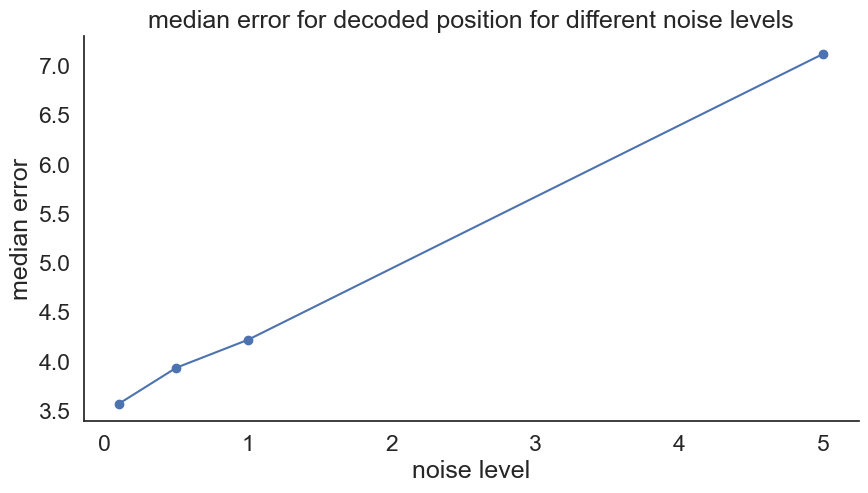

In [20]:
true_x = x[:-1]

median_errors = []

for n in noise_firing_rate:
    mse = np.sqrt((true_x-full_decoded[n])**2)
    median_errors.append(np.nanmedian(mse))

plt.plot(noise_firing_rate, median_errors, marker = "o")
plt.title("median error for decoded position for different noise levels")
plt.xlabel("noise level")
plt.ylabel("median error")

# When the noise level is increased, the firing rate maps and the true firing rate maps
# match less good, and the spike counts reflect the position-dependent spikes less well,
# so the information with what you decode the posotion is less accurate,
# so the decoded position has more errors in comparison to the true position,
# as noise is increased, whcih makes sense. This is also visible in the plot below,
# there seems to be about a linear relationship between noise level and median error of decoded position

## Exercise 2
---
In the loop implementation of the decoder, we used `poisson.logpmf(k,mu)` to calculate the log probability of observing $k$ spikes given an average firing rate of $\mu$. 
This is mathematically equivalent to `np.log(poisson.pmf(k,mu))`, in which we calculate the probability, and then take the log.


Re-run the decoding substituting this expression:

```
posterior[i] = sum(np.log(poisson.pmf(spikes_count[t_bin,:],firing_rate_maps[:,i]/fps)+pow(1,-15)))
```

To the line we are using to calculate the posterior.
Do you see any difference in the results? What do you think this is due to?




In [29]:
#original decoder with sum(poisson.logpmf(spikes_count etc.
# Run cell 3 and 5 again before this cell in run
true_x = x[:-1] # get rid of last timepoint to have same length as binned spikes
decoding_times = t[:-1]

x_decoded = np.zeros_like(true_x)

for t_bin in tqdm(range(len(decoding_times))):
    if sum(spikes_count[t_bin,:])>0: # Check if the time window contains spikes
        posterior = np.empty(firing_rate_maps.shape[-1])

        for i in range(len(posterior)):
            # Note that we work with log so that we can sum probabilities
            # instead of multiplying them 
            #posterior[i] = sum(np.log(poisson.pmf(spikes_count[t_bin,:],firing_rate_maps[:,i]/fps)+pow(1,-15)))
            posterior[i] = sum(poisson.logpmf(spikes_count[t_bin,:],firing_rate_maps[:,i]/fps)+pow(10,-15))


        x_decoded[t_bin] = space_bins[np.argmax(posterior)]
    else:
        x_decoded[t_bin] = np.nan

100%|██████████| 5026/5026 [00:07<00:00, 644.66it/s]


In [30]:
# new decoder with sum(np.log(poisson.pmf(spikes_count etc
x_decoded2 = np.zeros_like(true_x)

for t_bin in tqdm(range(len(decoding_times))):
    if sum(spikes_count[t_bin,:])>0: # Check if the time window contains spikes
        posterior2 = np.empty(firing_rate_maps.shape[-1])

        for i in range(len(posterior2)):
            # Note that we work with log so that we can sum probabilities
            # instead of multiplying them 
            posterior2[i] = sum(np.log(poisson.pmf(spikes_count[t_bin,:],firing_rate_maps[:,i]/fps)+pow(10,-15)))
           


        x_decoded2[t_bin] = space_bins[np.argmax(posterior2)]
    else:
        x_decoded2[t_bin] = np.nan 

100%|██████████| 5026/5026 [00:08<00:00, 589.92it/s]


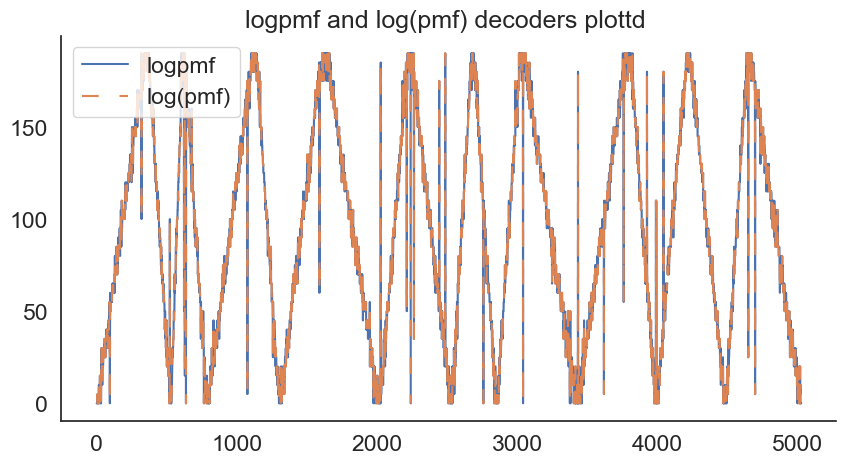

In [31]:
# plot the decoded positions and the true positions for both decoders
# in the cell beneath this one the other one is plotted
plt.figure(figsize=(10,5))
plt.plot(x_decoded,label= 'logpmf')
plt.plot(x_decoded2,label = 'log(pmf)', ls = "--", dashes = (8,10))
plt.title('logpmf and log(pmf) decoders plottd ')
plt.legend()

In [32]:
# calculate and plot the median errors for both methods
median_errors = []
median_errors.append(np.nanmedian(np.sqrt((true_x-x_decoded)**2)))
median_errors.append(np.nanmedian(np.sqrt((true_x-x_decoded2)**2)))

Text(0.5, 1.0, 'median errors of both decoding methods')

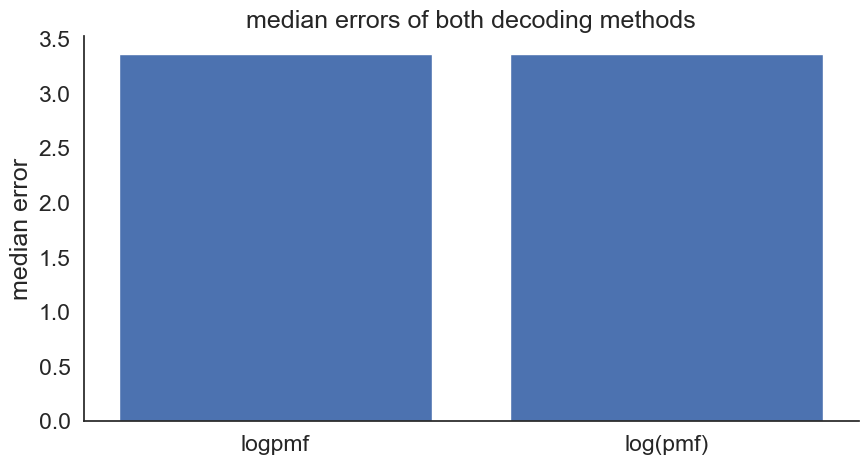

In [33]:
labels = ['logpmf', 'log(pmf)']
plt.bar(labels, median_errors)
plt.ylabel("median error")
plt.title("median errors of both decoding methods")

In [ ]:
# Both the decoded position with logpmf and log(pmf) methods get the same
# get the same decoded position. As you can see the plots precisely overline
# and the median errors for the true position are identical.

## Exercise 3
---
A - Estimate the quality of the sequence detection methods we saw in the lesson. How many false poistive does it find? How many false negatives?

B - Investigate the effect of `noise_x_react` and `noise_t_react` on the false positive rate and the false negative rate of our detection procedure.

C - What kind of sequence can our methods detect? What kind of activity, despide being sequential, could escape our detection method? Would you have an idea for a different method for sequence detection?


In [75]:
# generate data 

n_events = 200 # number of reactivation events
event_duration = 100 # in bins
sampling_rate = 100 # sampling rate 
t_react = np.arange(0,100)
noise_x_react=5; # Noise in the reactivation of the sequence
noise_t_react=5; # Noise in the timing of the spikes 
noise_firing_rate = 0.1 # the baseline noise firing rate


reactivation_events = np.zeros((n_events,event_duration))
spikes_react = np.zeros((n_events,n_cells,event_duration))

for event in range(n_events):
    if(event<=n_events//2):
    #Generate "real" sequences for the first half of events
        x_start = np.random.uniform(0,track_length) # Starting point
        x_end = np.random.uniform(0,track_length) # Ending point
        x_react = np.linspace(x_start,x_end,event_duration) \
            +np.random.normal(0,noise_x_react,size=event_duration)

    else:
        #Pick locations randomly for the second half 
        x_react = np.random.uniform(0,track_length,size=event_duration);

    x_react[x_react<0]=0;
    x_react[x_react>track_length]=track_length
    
    #store reactivation sequence
    reactivation_events[event,:] = x_react

    
    # Generate spikes according to the location being reactivated in this event
    
    for i in range(n_cells):
        binned_x = np.digitize(x_react,bins=np.linspace(0,track_length,firing_rate_maps.shape[-1]))-1
        inst_rate = firing_rate_maps[i,binned_x] + np.random.normal(0,noise_firing_rate,size=len(binned_x))
        inst_rate[inst_rate<0] = 0
        spikes_loc = np.where(np.random.poisson(inst_rate/sampling_rate)>0)
        spikes_loc = spikes_loc + np.round(np.random.normal(0,noise_t_react,size=len(spikes_loc)))
        spikes_loc = spikes_loc[np.logical_and(spikes_loc>0,spikes_loc<event_duration)]
        spikes_react[event,i,spikes_loc.astype(int)] = 1
        

In [76]:
time_window = 10 # number of bins to aggregate during decoding

reactivation_slope = np.zeros(n_events)

for event in range(n_events):

    event_spikes = spikes_react[event]
    # First we bin the events in windows of 10 bins
    spikes_sampled = np.zeros((n_cells,event_spikes.shape[1]//time_window))
    # We generate a new spike matrix with the re-sized window
    for t_r in range(1,event_spikes.shape[1]//time_window):
        spikes_sampled[:,t_r] = np.sum(event_spikes[:,(t_r-1)*time_window :(t_r)*time_window],axis=1)

In [77]:
# to do: bayesian decoding
t_resize = 10 # We use spikes from multiple time windows for the decoding

reactivation_slopes = np.zeros(n_events)
reactivation_pvalues = np.zeros(n_events)

for event in range(n_events):

    event_spikes = spikes_react[event]
    spikes_sampled = np.zeros((n_cells,event_spikes.shape[1]//t_resize))

    # We generate a new spike matrix with the re-sized window
    for t_r in range(1,event_spikes.shape[1]//t_resize):
        spikes_sampled[:,t_r] = np.sum(event_spikes[:,(t_r-1)*t_resize :(t_r)*t_resize],axis=1)


    # We then perform decoding on the aggregated spikes
    x_decoded = np.zeros(spikes_sampled.shape[1])

    for t_bin in range(spikes_sampled.shape[1]):

        if sum(spikes_count[t_bin,:])>0: # Check if the time window contains spikes

            posterior = np.empty(firing_rate_maps.shape[-1])
            for i in range(len(posterior)):
                posterior[i] = sum(poisson.logpmf(spikes_sampled[:,t_bin],firing_rate_maps[:,i]*t_resize/fps)+pow(1,-15))

            x_decoded[t_bin] = space_bins[np.argmax(posterior)]

        else:
            x_decoded[t_bin] = np.nan   

        # We fit a line to the decoded positions, and save the slope
        slope,_ = np.polyfit(np.arange(len(x_decoded)),x_decoded,deg=1)
        reactivation_slopes[event] = slope
        # And calculate the pvalue of the pearson correlation
        corr = pearsonr(np.arange(len(x_decoded)),x_decoded)
        reactivation_pvalues[event] = corr[1]


C:\Users\larsb\AppData\Local\Temp\ipykernel_19632\1835679459.py:37: ConstantInputWarning: An input array is constant; the correlation coefficient is not defined.
  corr = pearsonr(np.arange(len(x_decoded)),x_decoded)


In [ ]:
#A A p value smaller than 0.05 means a significant slope so it is
# decoded as a sequence event, so check whether all pvalues smaller than 0.05
# belong to event 0-100 and all pvalues of > 0.0 belong to event 101-199 (non-sequence events)

sequence_pvalues = reactivation_pvalues[0:101]
nonsequence_pvalues = reactivation_pvalues[101:200]

false_negatives = 0
for pvalue in sequence_pvalues:
    if pvalue > 0.05:
        false_negatives +=1

false_positives = 0
for pvalue in nonsequence_pvalues:
    if pvalue <= 0.05:
        false_positives +=1

print(f"# of false negatives = {false_negatives}\n"
      f"# of false positives = {false_positives}")

# I get 90 false negatives which is 90%. This is a lot, most of the sequence events
# are seen as non-sequence events, I dont know why this is
# I get 10 false positives, which means 10% of the non sequence events is decoded as sequence event

# of false negatives = 90
# of false positives = 10


In [ ]:
#B
# make a fucntion generate data where you can put in different levels of noise 
def generate_data(noise_x, noise_t):
    n_events = 200 # number of reactivation events
    event_duration = 100 # in bins
    sampling_rate = 100 # sampling rate 
    t_react = np.arange(0,100)
    noise_x_react= noise_x; # Noise in the reactivation of the sequence
    noise_t_react= noise_t; # Noise in the timing of the spikes 
    noise_firing_rate = 0.1 # the baseline noise firing rate


    reactivation_events = np.zeros((n_events,event_duration))
    spikes_react = np.zeros((n_events,n_cells,event_duration))

    for event in range(n_events):
        if(event<=n_events//2):
        #Generate "real" sequences for the first half of events
            x_start = np.random.uniform(0,track_length) # Starting point
            x_end = np.random.uniform(0,track_length) # Ending point
            x_react = np.linspace(x_start,x_end,event_duration) \
                +np.random.normal(0,noise_x_react,size=event_duration)

        else:
            #Pick locations randomly for the second half 
            x_react = np.random.uniform(0,track_length,size=event_duration);

        x_react[x_react<0]=0;
        x_react[x_react>track_length]=track_length
        
        #store reactivation sequence
        reactivation_events[event,:] = x_react

        
        # Generate spikes according to the location being reactivated in this event
        
        for i in range(n_cells):
            binned_x = np.digitize(x_react,bins=np.linspace(0,track_length,firing_rate_maps.shape[-1]))-1
            inst_rate = firing_rate_maps[i,binned_x] + np.random.normal(0,noise_firing_rate,size=len(binned_x))
            inst_rate[inst_rate<0] = 0
            spikes_loc = np.where(np.random.poisson(inst_rate/sampling_rate)>0)
            spikes_loc = spikes_loc + np.round(np.random.normal(0,noise_t_react,size=len(spikes_loc)))
            spikes_loc = spikes_loc[np.logical_and(spikes_loc>0,spikes_loc<event_duration)]
            spikes_react[event,i,spikes_loc.astype(int)] = 1
    return spikes_react
            

In [ ]:
# Generate the data with different levels of noise and put them in a data structure
spikes_react0 = generate_data(0,0)
spikes_react5 = generate_data(5,5)
spikes_react10 = generate_data(10,10)
spikes_react20 = generate_data(20,20)

total_spikes_react = [spikes_react0,
                      spikes_react5,
                      spikes_react10,
                      spikes_react20]

In [ ]:
# Do the baysian decoding for all spikes_react with different noise levels
# via a for loop 
reactivation_slopes = np.zeros((len(total_spikes_react), n_events))
reactivation_pvalues = np.zeros((len(total_spikes_react), n_events))

for j, spikes_react in enumerate(total_spikes_react):

    time_window = 10 # number of bins to aggregate during decoding

    reactivation_slope = np.zeros(n_events)

    for event in range(n_events):

        event_spikes = spikes_react[event]
        # First we bin the events in windows of 10 bins
        spikes_sampled = np.zeros((n_cells,event_spikes.shape[1]//time_window))
        # We generate a new spike matrix with the re-sized window
        for t_r in range(1,event_spikes.shape[1]//time_window):
            spikes_sampled[:,t_r] = np.sum(event_spikes[:,(t_r-1)*time_window :(t_r)*time_window],axis=1)
    



        # to do: bayesian decoding
    t_resize = 10 # We use spikes from multiple time windows for the decoding



    for event in range(n_events):

        event_spikes = spikes_react[event]
        spikes_sampled = np.zeros((n_cells,event_spikes.shape[1]//t_resize))

        # We generate a new spike matrix with the re-sized window
        for t_r in range(1,event_spikes.shape[1]//t_resize):
            spikes_sampled[:,t_r] = np.sum(event_spikes[:,(t_r-1)*t_resize :(t_r)*t_resize],axis=1)


        # We then perform decoding on the aggregated spikes
        x_decoded = np.zeros(spikes_sampled.shape[1])

        for t_bin in range(spikes_sampled.shape[1]):

            if sum(spikes_count[t_bin,:])>0: # Check if the time window contains spikes

                posterior = np.empty(firing_rate_maps.shape[-1])
                for i in range(len(posterior)):
                    posterior[i] = sum(poisson.logpmf(spikes_sampled[:,t_bin],firing_rate_maps[:,i]*t_resize/fps)+pow(1,-15))

                x_decoded[t_bin] = space_bins[np.argmax(posterior)]

            else:
                x_decoded[t_bin] = np.nan   

            # We fit a line to the decoded positions, and save the slope
            slope,_ = np.polyfit(np.arange(len(x_decoded)),x_decoded,deg=1)
            reactivation_slopes[j][event] = slope
            # And calculate the pvalue of the pearson correlation
            corr = pearsonr(np.arange(len(x_decoded)),x_decoded)
            reactivation_pvalues[j][event] = corr[1]


C:\Users\larsb\AppData\Local\Temp\ipykernel_19632\3050627214.py:57: ConstantInputWarning: An input array is constant; the correlation coefficient is not defined.
  corr = pearsonr(np.arange(len(x_decoded)),x_decoded)


In [69]:
total_fnegatives = []
total_fpositives = []
for i in range(len(total_spikes_react)):

    sequence_pvalues = reactivation_pvalues[i, 0:101]
    nonsequence_pvalues = reactivation_pvalues[i, 101:200]

    false_negatives = 0
    for pvalue in sequence_pvalues:
        if pvalue > 0.05:
            false_negatives +=1
    total_fnegatives.append(false_negatives)

    false_positives = 0
    for pvalue in nonsequence_pvalues:
        if pvalue <= 0.05:
            false_positives +=1
    total_fpositives.append(false_positives)


[86, 94, 92, 90] [5, 3, 4, 10]


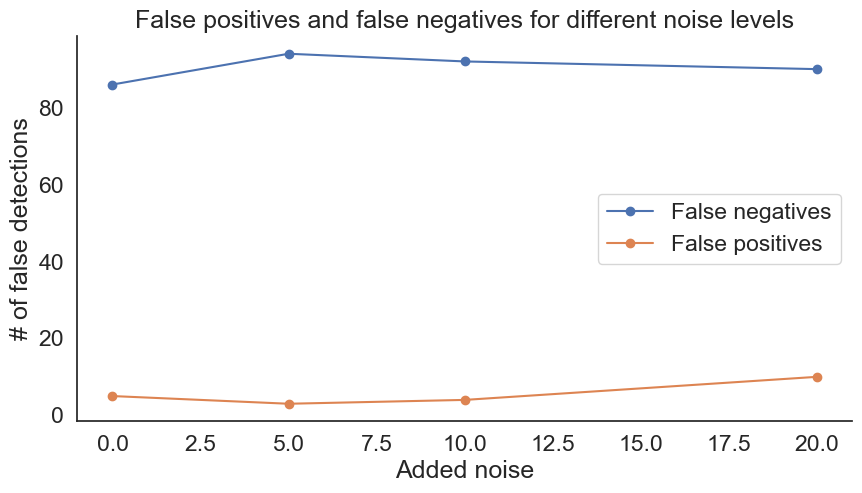

In [80]:
noise_list = [0, 5, 10, 20]

plt.plot(noise_list, total_fnegatives, 
         marker = "o", label = "False negatives")
plt.plot(noise_list, total_fpositives,
         marker = "o", label = "False positives")
plt.legend()
plt.title("False positives and false negatives for different noise levels")
plt.xlabel("Added noise")
plt.ylabel("# of false detections")

print(total_fnegatives, total_fpositives)

# The noise level does not seem to strongly affect the number of false
# negatives and false positives. The number of false negatives stays around
# 90, while the number of false positives stays around 5.
# This is unexpected, because with 0 noise the sequence events should be
# easier to decode. Therefore, the high number of false negatives suggests
# that something may be wrong in the decoding or sequence detection step.

In [ ]:
# C
# This method detects significant slopes as true sequences. This means
# that only sequences where the position in an event goes up or down
# are detected as true sequences. Events where the position may go up,
# then down and then up again do not give a significant slope, and thus
# are not detected as sequences, while in reality they might be

# By fitting multiple sections within an event, changes in the direction of the
# decoded position can still be captured. This would allow non-linear or
# back-and-forth sequences to be detected as sequences.

### Code for data generation

In [12]:
import numpy as np
import scipy
import scipy.stats
import scipy.io
import matplotlib
import matplotlib.pyplot as plt

%matplotlib inline 
plt.rcParams['figure.figsize'] = [10, 5]
from ipywidgets import interact
import ipywidgets as widgets


track_length = 200. # the length of our linear track (eg in centimeter)
average_firing_rate = 5 # the peak firing rate, averaged across the population 
n_cells = 100 # how many cells we are recording
pf_centers = np.random.rand(n_cells) * track_length # the centers of the place fields for all cells drawn randomly with a uniform distribution on the track
pf_size = np.random.gamma(10, size=n_cells) # the size (width) of the place fields, drawn randomly from a gamma distribution 
pf_rate = np.random.exponential(scale=average_firing_rate, size=n_cells) # the peak firing rate for each cell, drawn from an exponential distribution

In [13]:
bins = np.arange(0., 200.)
true_firing_rate_maps = np.zeros((n_cells, len(bins)))
for i in range(n_cells):
    true_firing_rate_maps[i,:] = pf_rate[i] * np.exp(-((bins-pf_centers[i])**2)/(2*pf_size[i]**2))

In [14]:
# GENERATE TRAJECTORY

n_runs = 10
use_stops = False
av_running_speed = 10 # the average running speed (in cm/s)
fps = 10 # the number of "video frames" per second 
running_speed_a = np.random.chisquare(10, size=n_runs) # running speed in the two directions
running_speed_b = np.random.chisquare(10, size=n_runs) 

stopping_time_a = np.random.chisquare(15, size=n_runs) # the time the mouse will spend at the two ends of the track
stopping_time_b = np.random.chisquare(15, size=n_runs)

x = np.array([])


for i in range(n_runs):
    stop1 = np.ones((int(stopping_time_a[i]*fps),)) * 0.
    run_length = len(bins) * fps / running_speed_a[i]
    run1 = np.linspace(0., float(len(bins)-1), int(run_length))
    stop2 = np.ones((int(stopping_time_b[i]*fps),)) * (len(bins)-1.)
    run_length = len(bins) * fps / running_speed_b[i]
    run2 = np.linspace(len(bins)-1., 0., int(run_length))
    if use_stops:
        x = np.concatenate((x, stop1, run1, stop2, run2))
    else:
         x = np.concatenate((x, run1, run2))
t = np.arange(len(x))/fps

In [15]:
sampling_rate = 10000.
t_sampling = np.arange(0, t[-1], 1. / sampling_rate)
x_sampling = np.floor(np.interp(t_sampling, t, x))
noise_firing_rate = [0.1, 0.5, 1, 5] # the baseline noise firing rate
spikes = {noise : [] for noise in noise_firing_rate}
for n in noise_firing_rate:
    for i in range(n_cells):
        inst_rate = true_firing_rate_maps[i,x_sampling.astype(np.int32)] + n
        spikes_loc = np.random.poisson(inst_rate/sampling_rate)
        sp = np.argwhere(spikes_loc)
        t_sp = t_sampling[sp]
        spikes[n].append(t_sp)

In [16]:
import pickle

file_name = 'linear_track_data_new.pickle' # change this name when you save new data

out_data = {}
out_data['x'] = x
out_data['t'] = t
out_data['spikes'] = spikes
out_data['track_length'] = track_length
out_data['fps'] = fps

with open('data/'+file_name,'wb') as f:
    pickle.dump(out_data,f)